In [32]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm

import holodeck as holo
from holodeck import sams
from holodeck import utils, plot
from holodeck.constants import MSOL, YR, PC

holo.log.setLevel(holo.log.ERROR)

passed redz check at the beginning of ss_gws_redz()


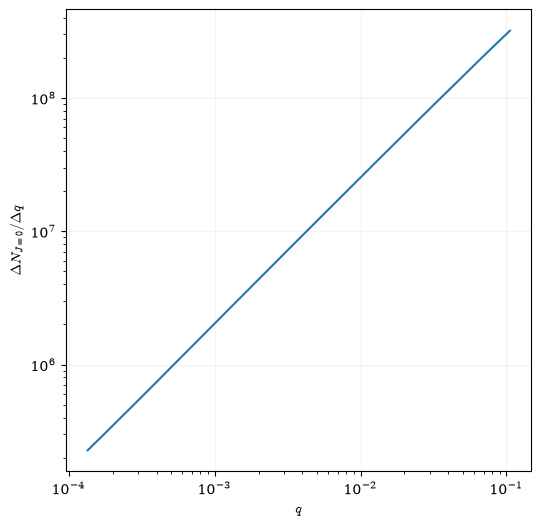

In [39]:
shape = 30
NUM_REALS = 100
NUM_LOUDEST = 1

gsmf = holo.sams.GSMF_Schechter()                    # Galaxy Stellar-Mass Function (GSMF)
gpf = holo.sams.GPF_Power_Law()                      # Galaxy Pair Fraction         (GPF)
gmt = holo.sams.GMT_Power_Law()                      # Galaxy Merger Time           (GMT)
mmbulge = holo.host_relations.MMBulge_MM2013()       # M-MBulge Relation            (MMB)
sam = holo.sams.Semi_Analytic_Model(gsmf=gsmf, gpf=gpf, gmt=gmt, mmbulge=mmbulge, shape=shape)
# sam = sams.Semi_Analytic_Model(shape=shape)

OBS_DUR = 10.0 * YR
NUM_FREQS = 20
fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)

hc_ss, hc_bg = sam.gwb(fobs_edges, realize=NUM_REALS, loudest=NUM_LOUDEST)

hard_gw = holo.hardening.Hard_GW()

lifetime = 1e9 * YR  ## <-- try changing this
gamma_inner = -1.0 ## <-- try changing this
hard_ph = holo.hardening.Fixed_Time_2PL_SAM(sam, lifetime, sepa_init=1.0e4*PC, gamma_inner=gamma_inner)
redz_final, diff_num = holo.sams.sam_cyutils.dynamic_binary_number_at_fobs(
    fobs, sam, hard_ph, holo.cosmo
)

edges = [sam.mtot, sam.mrat, sam.redz, fobs_edges]
number = holo.sams.sam_cyutils.integrate_differential_number_3dx1d(edges, diff_num)


NJ = np.sum(number[:,:,:,0], (0,2))

fig, axs = plt.subplots(figsize=(6,6))
axs.loglog( (sam.mrat[1:] - sam.mrat[:-1])/2 , NJ)
axs.set_xlabel(r"$q$")
axs.set_ylabel(r"$\Delta N_{J=0}/\Delta q$")
fig.show()

In [ ]:
NJ = np.sum(number, (0,2,3))

array([3.16880878e-09, 6.33761756e-09, 9.50642634e-09, 1.26752351e-08,
       1.58440439e-08, 1.90128527e-08, 2.21816615e-08, 2.53504703e-08,
       2.85192790e-08, 3.16880878e-08, 3.48568966e-08, 3.80257054e-08,
       4.11945142e-08, 4.43633229e-08, 4.75321317e-08, 5.07009405e-08,
       5.38697493e-08, 5.70385581e-08, 6.02073668e-08, 6.33761756e-08])

In [3]:
hc_bg_J = np.sum(hc_bg, 1)
f_avg_J_yr = fobs * YR
AJ = (hc_bg_J * (f_avg_J_yr)**(2/3)) / NJ